In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (accuracy_score, confusion_matrix,
                                      classification_report, roc_auc_score,
                                      roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.svm              import SVC
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import (RandomForestClassifier,
                                      GradientBoostingClassifier,
                                      AdaBoostClassifier)
from xgboost import XGBClassifier
import joblib

PALETTE = ["#E74C3C", "#3498DB"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


In [6]:
df = pd.read_csv("train.csv", index_col=0)

col_meta = {
    "age":      "Age in years",
    "sex":      "Sex (1=male, 0=female)",
    "cp":       "Chest pain type (0-3)",
    "trestbps": "Resting blood pressure (mmHg)",
    "chol":     "Serum cholesterol (mg/dl)",
    "fbs":      "Fasting blood sugar > 120 mg/dl (1=True)",
    "restecg":  "Resting ECG results (0-2)",
    "thalach":  "Maximum heart rate achieved",
    "exang":    "Exercise-induced angina (1=yes)",
    "oldpeak":  "ST depression induced by exercise",
    "slope":    "Slope of peak exercise ST segment (0-2)",
    "ca":       "Number of major vessels coloured by fluoroscopy (0-3)",
    "thal":     "Thalassemia (1=normal, 2=fixed defect, 3=reversible defect)",
    "target":   "Heart disease (1=present, 0=absent)"
}

print(f"Dataset shape : {df.shape}")
print("\nColumn descriptions:")
for c, d in col_meta.items():
    print(f"  {c:<10} => {d}")

Dataset shape : (242, 14)

Column descriptions:
  age        => Age in years
  sex        => Sex (1=male, 0=female)
  cp         => Chest pain type (0-3)
  trestbps   => Resting blood pressure (mmHg)
  chol       => Serum cholesterol (mg/dl)
  fbs        => Fasting blood sugar > 120 mg/dl (1=True)
  restecg    => Resting ECG results (0-2)
  thalach    => Maximum heart rate achieved
  exang      => Exercise-induced angina (1=yes)
  oldpeak    => ST depression induced by exercise
  slope      => Slope of peak exercise ST segment (0-2)
  ca         => Number of major vessels coloured by fluoroscopy (0-3)
  thal       => Thalassemia (1=normal, 2=fixed defect, 3=reversible defect)
  target     => Heart disease (1=present, 0=absent)


In [7]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2,1
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3,0
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2,1
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3,0
59,57,0,0,128,303,0,0,159,0,0.0,2,1,2,1
93,54,0,1,132,288,1,0,159,1,0.0,2,1,2,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2,0
30,41,0,1,105,198,0,1,168,0,0.0,2,1,2,1


In [9]:
df.describe().T.style.background_gradient(cmap="magma")

,count,mean,std,min,25%,50%,75%,max
age,242.000000,54.462810,9.204492,29.000000,48.000000,55.500000,61.000000,77.000000
sex,242.000000,0.657025,0.475687,0.000000,0.000000,1.000000,1.000000,1.000000
cp,242.000000,0.991736,1.022533,0.000000,0.000000,1.000000,2.000000,3.000000
trestbps,242.000000,130.359504,16.828858,94.000000,120.000000,130.000000,140.000000,192.000000
chol,242.000000,246.842975,52.795465,131.000000,212.000000,239.500000,274.750000,564.000000
fbs,242.000000,0.128099,0.334893,0.000000,0.000000,0.000000,0.000000,1.000000
restecg,242.000000,0.553719,0.530410,0.000000,0.000000,1.000000,1.000000,2.000000
thalach,242.000000,150.115702,22.352398,88.000000,136.000000,154.000000,165.750000,202.000000
exang,242.000000,0.314050,0.465098,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,242.000000,1.013223,1.102577,0.000000,0.000000,0.800000,1.600000,5.600000


In [10]:
print("=" * 50)
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\nData types:")
print(df.dtypes)

df = df.drop_duplicates().reset_index(drop=True)
print(f"\nShape after dedup: {df.shape}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 1

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Shape after dedup: (241, 14)


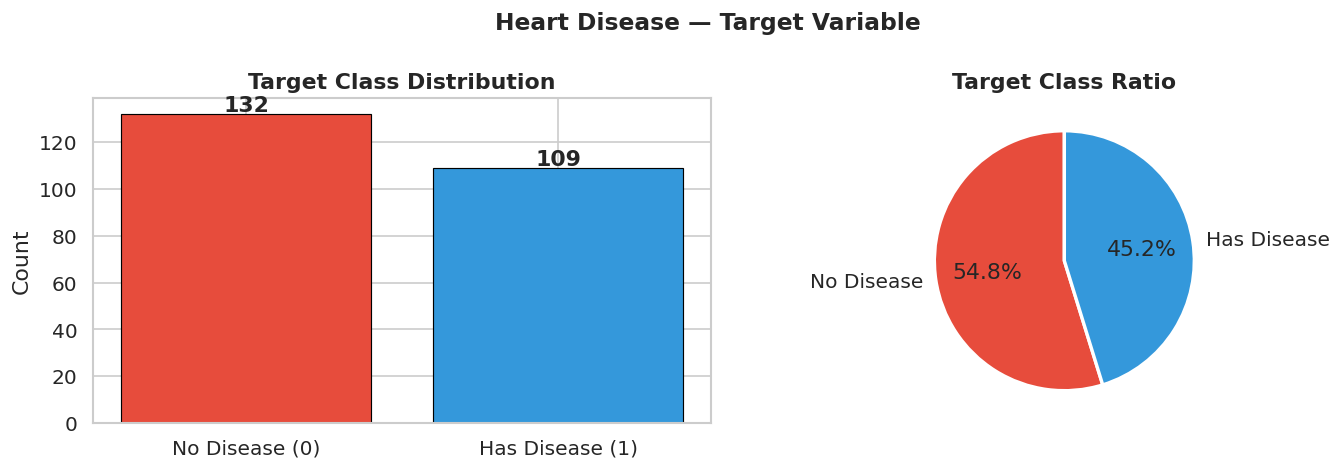


Class balance:
target
1    54.77
0    45.23
Name: count, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df["target"].value_counts()
axes[0].bar(["No Disease (0)", "Has Disease (1)"], target_counts,
            color=PALETTE, edgecolor="black", linewidth=0.7)
axes[0].set_title("Target Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

axes[1].pie(target_counts, labels=["No Disease", "Has Disease"],
            autopct="%1.1f%%", colors=PALETTE, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Target Class Ratio", fontweight="bold")

plt.suptitle("Heart Disease — Target Variable", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\nClass balance:\n{(target_counts / len(df) * 100).round(2)}")

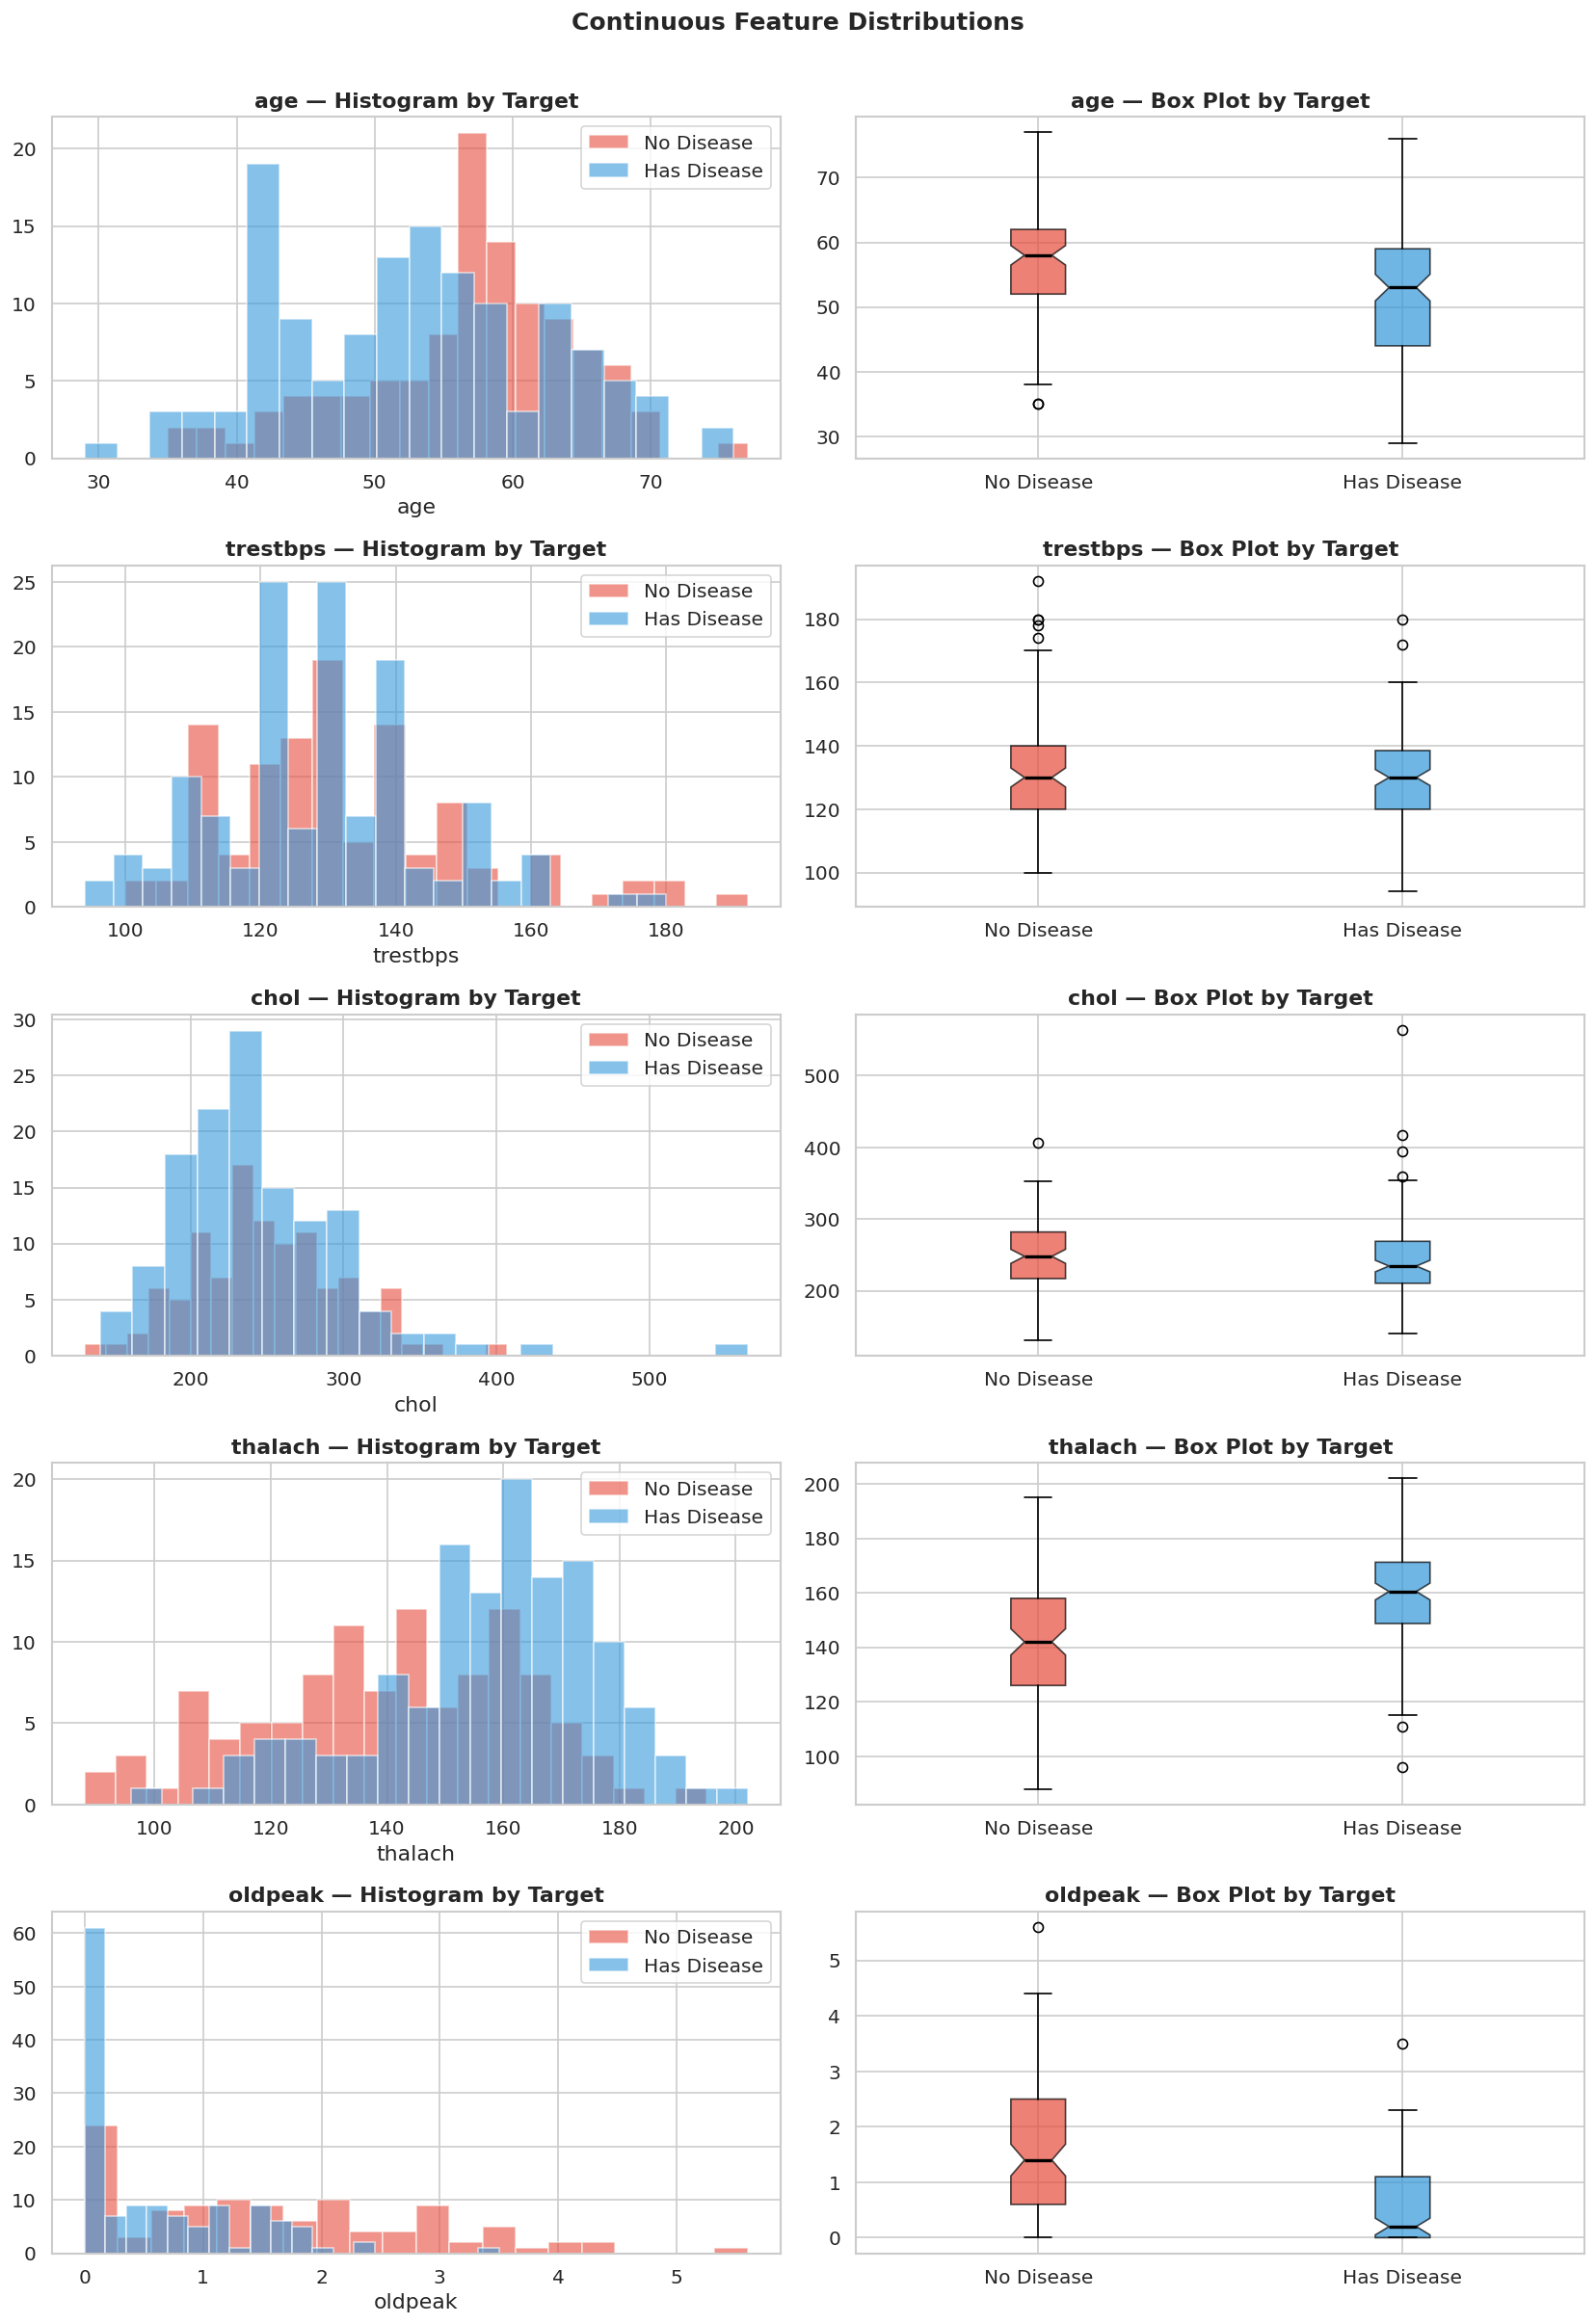

In [12]:
continuous = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(len(continuous), 2, figsize=(14, 4 * len(continuous)))

for i, col in enumerate(continuous):
    for t, lbl in [(0, "No Disease"), (1, "Has Disease")]:
        subset = df[df["target"] == t][col]
        axes[i, 0].hist(subset, bins=20, alpha=0.6,
                        color=PALETTE[t], label=lbl, edgecolor="white")
    axes[i, 0].set_title(f"{col} — Histogram by Target", fontweight="bold")
    axes[i, 0].legend()
    axes[i, 0].set_xlabel(col)

    bp = axes[i, 1].boxplot(
        [df[df["target"] == 0][col], df[df["target"] == 1][col]],
        patch_artist=True, notch=True,
        medianprops={"color": "black", "linewidth": 2}
    )
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_xticks([1, 2])
    axes[i, 1].set_xticklabels(["No Disease", "Has Disease"])
    axes[i, 1].set_title(f"{col} — Box Plot by Target", fontweight="bold")

plt.suptitle("Continuous Feature Distributions", fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

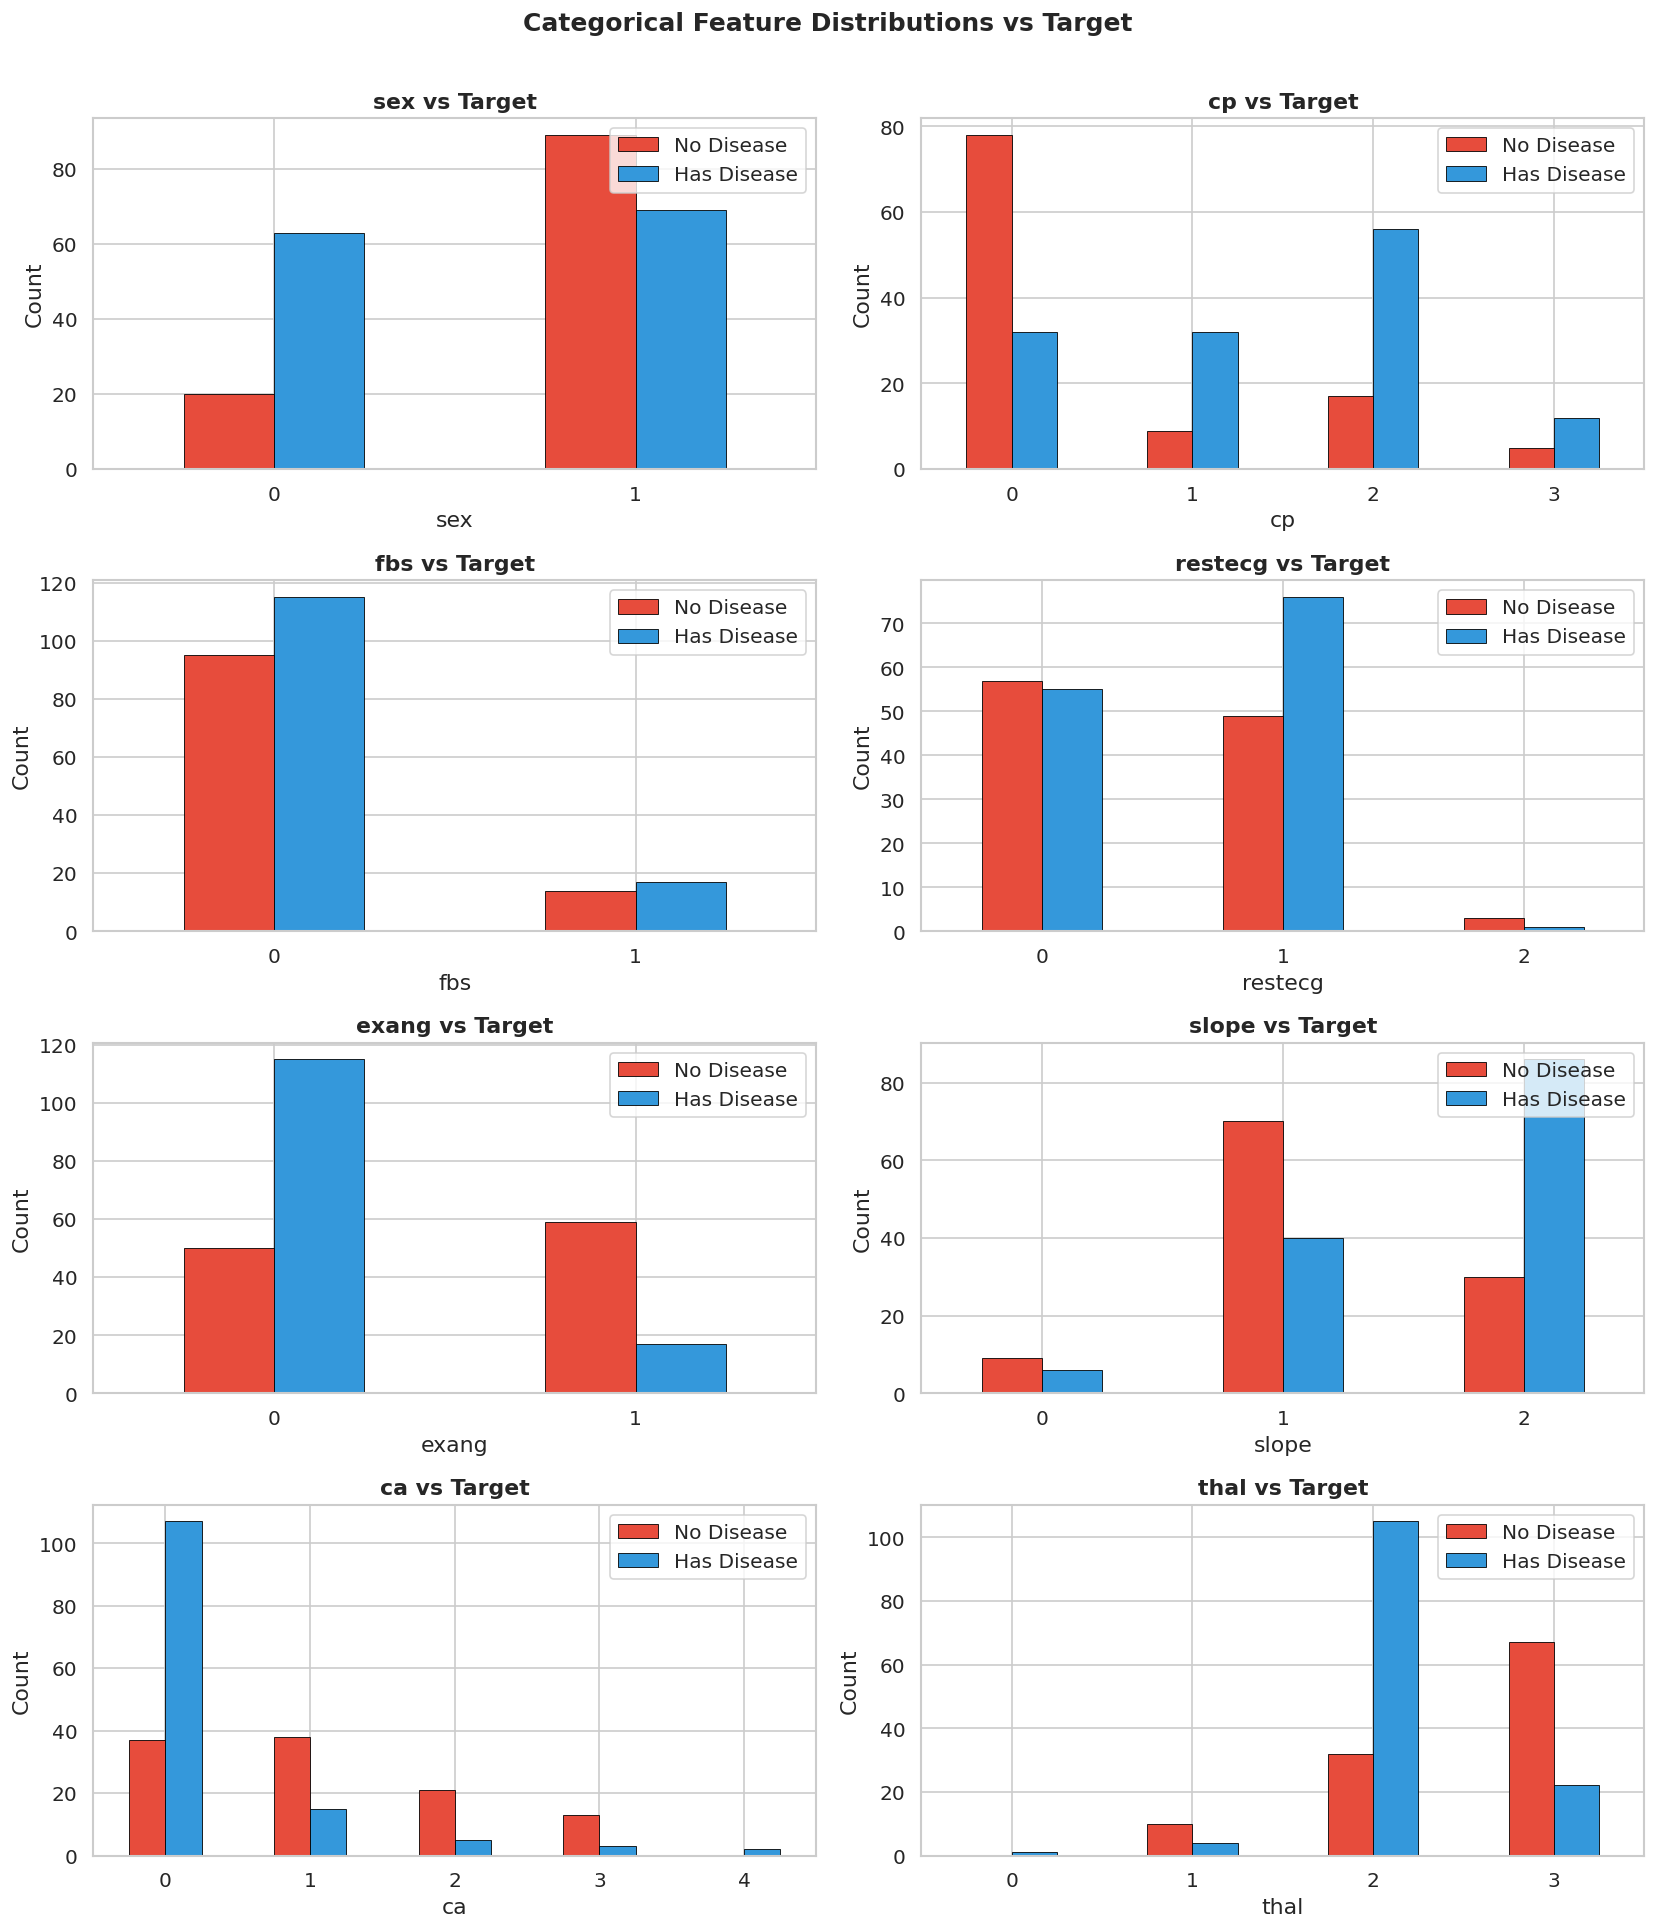

In [13]:
categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical):
    ct = pd.crosstab(df[col], df["target"])
    ct.plot(kind="bar", ax=axes[i], color=PALETTE, edgecolor="black",
            linewidth=0.5, rot=0)
    axes[i].set_title(f"{col} vs Target", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(["No Disease", "Has Disease"], loc="upper right")

plt.suptitle("Categorical Feature Distributions vs Target",
             fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

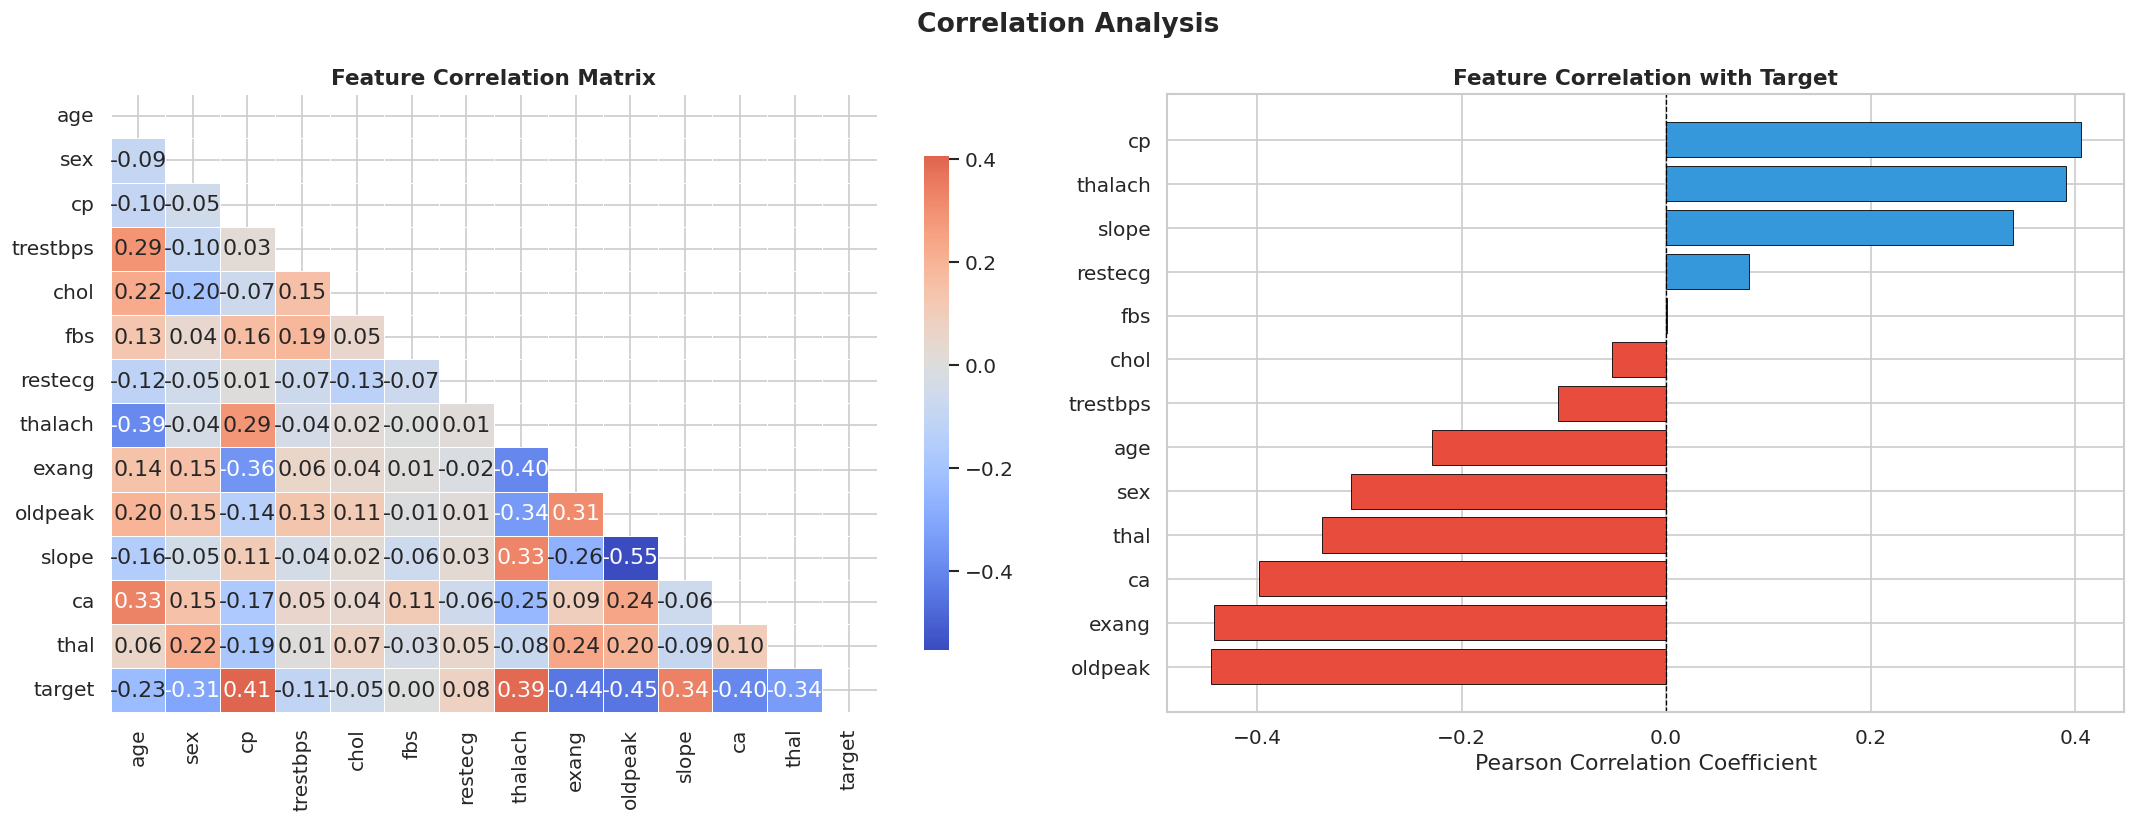


Top features correlated with target (by absolute value):
oldpeak     0.445386
exang       0.441847
cp          0.405567
ca          0.398077
thalach     0.391081
slope       0.339210
thal        0.336896
sex         0.307726
age         0.228968
trestbps    0.106192
restecg     0.081121
chol        0.052886
fbs         0.000517


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=axes[0], center=0,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)

target_corr = corr["target"].drop("target").sort_values()
colors_bar  = ["#E74C3C" if v < 0 else "#3498DB" for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar,
             edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Feature Correlation with Target", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Pearson Correlation Coefficient")

plt.suptitle("Correlation Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop features correlated with target (by absolute value):")
print(target_corr.abs().sort_values(ascending=False).to_string())

In [15]:
print(f"{'Feature':<12} {'Correlation':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 52)
for col in df.columns.drop("target"):
    corr_val, pval = pointbiserialr(df[col], df["target"])
    sig = "Yes" if pval < 0.05 else "No"
    print(f"{col:<12} {corr_val:>12.4f} {pval:>12.4f} {sig:>12}")

Feature       Correlation      p-value  Significant
----------------------------------------------------
age               -0.2290       0.0003          Yes
sex               -0.3077       0.0000          Yes
cp                 0.4056       0.0000          Yes
trestbps          -0.1062       0.1000           No
chol              -0.0529       0.4137           No
fbs                0.0005       0.9936           No
restecg            0.0811       0.2095           No
thalach            0.3911       0.0000          Yes
exang             -0.4418       0.0000          Yes
oldpeak           -0.4454       0.0000          Yes
slope              0.3392       0.0000          Yes
ca                -0.3981       0.0000          Yes
thal              -0.3369       0.0000          Yes


In [16]:
df_model = df.copy()
cat_ohe  = ["cp", "slope", "thal"]
df_model = pd.get_dummies(df_model, columns=cat_ohe, drop_first=True)

X = df_model.drop("target", axis=1)
y = df_model["target"]

print(f"Feature matrix shape: {X.shape}")
print(f"Features used:\n{list(X.columns)}")

Feature matrix shape: (241, 18)
Features used:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train_sc.shape}")
print(f"Test  size : {X_test_sc.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest  target distribution:\n{y_test.value_counts()}")


Train size : (192, 18)
Test  size : (49, 18)

Train target distribution:
target
1    105
0     87
Name: count, dtype: int64

Test  target distribution:
target
1    27
0    22
Name: count, dtype: int64


In [18]:
def evaluate_model(name, model, Xtr, Xte, ytr, yte, cv=5):
    model.fit(Xtr, ytr)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None

    acc_train = accuracy_score(ytr, model.predict(Xtr))
    acc_test  = accuracy_score(yte, y_pred)
    auc       = roc_auc_score(yte, y_proba) if y_proba is not None else None
    cv_scores = cross_val_score(
        model, Xtr, ytr,
        cv=StratifiedKFold(cv, shuffle=True, random_state=42),
        scoring="accuracy"
    )

    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(f"  Train Accuracy : {acc_train:.4f}")
    print(f"  Test  Accuracy : {acc_test:.4f}")
    if auc:
        print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  CV ({cv}-fold) Mean : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(classification_report(yte, y_pred,
                                target_names=["No Disease", "Has Disease"]))

    return {
        "Model":    name,
        "Train Acc": acc_train,
        "Test Acc":  acc_test,
        "ROC-AUC":   auc,
        "CV Mean":   cv_scores.mean(),
        "CV Std":    cv_scores.std(),
        "_model":    model,
        "_y_pred":   y_pred,
        "_y_proba":  y_proba,
    }

results = []

In [19]:
lr = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_model('Logistic Regression', lr, X_train_sc, X_test_sc, y_train, y_test))

  Logistic Regression
  Train Accuracy : 0.8698
  Test  Accuracy : 0.7959
  ROC-AUC        : 0.8434
  CV (5-fold) Mean : 0.8018 +/- 0.0490
              precision    recall  f1-score   support

  No Disease       0.88      0.64      0.74        22
 Has Disease       0.76      0.93      0.83        27

    accuracy                           0.80        49
   macro avg       0.82      0.78      0.79        49
weighted avg       0.81      0.80      0.79        49



In [20]:
knn = KNeighborsClassifier(n_neighbors=7)
results.append(evaluate_model('K-Nearest Neighbours', knn, X_train_sc, X_test_sc, y_train, y_test))

  K-Nearest Neighbours
  Train Accuracy : 0.8385
  Test  Accuracy : 0.7959
  ROC-AUC        : 0.8670
  CV (5-fold) Mean : 0.7965 +/- 0.0432
              precision    recall  f1-score   support

  No Disease       0.83      0.68      0.75        22
 Has Disease       0.77      0.89      0.83        27

    accuracy                           0.80        49
   macro avg       0.80      0.79      0.79        49
weighted avg       0.80      0.80      0.79        49



In [21]:
svm = SVC(C=10, gamma=0.01, kernel='rbf', probability=True, random_state=42)
results.append(evaluate_model('SVM (RBF)', svm, X_train_sc, X_test_sc, y_train, y_test))

  SVM (RBF)
  Train Accuracy : 0.9271
  Test  Accuracy : 0.7959
  ROC-AUC        : 0.8535
  CV (5-fold) Mean : 0.8018 +/- 0.0436
              precision    recall  f1-score   support

  No Disease       0.88      0.64      0.74        22
 Has Disease       0.76      0.93      0.83        27

    accuracy                           0.80        49
   macro avg       0.82      0.78      0.79        49
weighted avg       0.81      0.80      0.79        49



In [22]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4, random_state=42)
results.append(evaluate_model('Decision Tree', dt, X_train_sc, X_test_sc, y_train, y_test))

  Decision Tree
  Train Accuracy : 0.8906
  Test  Accuracy : 0.7551
  ROC-AUC        : 0.8056
  CV (5-fold) Mean : 0.7605 +/- 0.0768
              precision    recall  f1-score   support

  No Disease       0.81      0.59      0.68        22
 Has Disease       0.73      0.89      0.80        27

    accuracy                           0.76        49
   macro avg       0.77      0.74      0.74        49
weighted avg       0.77      0.76      0.75        49



In [23]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2,
                            max_features='sqrt', random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf, X_train_sc, X_test_sc, y_train, y_test))

  Random Forest
  Train Accuracy : 0.9844
  Test  Accuracy : 0.7551
  ROC-AUC        : 0.8704
  CV (5-fold) Mean : 0.7969 +/- 0.0603
              precision    recall  f1-score   support

  No Disease       0.78      0.64      0.70        22
 Has Disease       0.74      0.85      0.79        27

    accuracy                           0.76        49
   macro avg       0.76      0.74      0.75        49
weighted avg       0.76      0.76      0.75        49



In [24]:
gbc = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
results.append(evaluate_model('Gradient Boosting', gbc, X_train_sc, X_test_sc, y_train, y_test))

  Gradient Boosting
  Train Accuracy : 1.0000
  Test  Accuracy : 0.7551
  ROC-AUC        : 0.8350
  CV (5-fold) Mean : 0.7652 +/- 0.0698
              precision    recall  f1-score   support

  No Disease       0.81      0.59      0.68        22
 Has Disease       0.73      0.89      0.80        27

    accuracy                           0.76        49
   macro avg       0.77      0.74      0.74        49
weighted avg       0.77      0.76      0.75        49



In [25]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
results.append(evaluate_model('AdaBoost', ada, X_train_sc, X_test_sc, y_train, y_test))

  AdaBoost
  Train Accuracy : 0.9115
  Test  Accuracy : 0.7755
  ROC-AUC        : 0.8721
  CV (5-fold) Mean : 0.8115 +/- 0.0882
              precision    recall  f1-score   support

  No Disease       0.79      0.68      0.73        22
 Has Disease       0.77      0.85      0.81        27

    accuracy                           0.78        49
   macro avg       0.78      0.77      0.77        49
weighted avg       0.78      0.78      0.77        49



In [26]:
xgb = XGBClassifier(objective='binary:logistic', n_estimators=200,
                    learning_rate=0.05, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, eval_metric='logloss',
                    random_state=42, verbosity=0)
results.append(evaluate_model('XGBoost', xgb, X_train_sc, X_test_sc, y_train, y_test))

  XGBoost
  Train Accuracy : 1.0000
  Test  Accuracy : 0.7347
  ROC-AUC        : 0.8418
  CV (5-fold) Mean : 0.7760 +/- 0.0679
              precision    recall  f1-score   support

  No Disease       0.76      0.59      0.67        22
 Has Disease       0.72      0.85      0.78        27

    accuracy                           0.73        49
   macro avg       0.74      0.72      0.72        49
weighted avg       0.74      0.73      0.73        49



In [27]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in results
])
results_df = results_df.sort_values("Test Acc", ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.style.background_gradient(
    subset=["Test Acc", "ROC-AUC", "CV Mean"], cmap="Greens"
).format({"Train Acc": "{:.4f}", "Test Acc": "{:.4f}",
          "ROC-AUC": "{:.4f}", "CV Mean": "{:.4f}", "CV Std": "{:.4f}"})

,Model,Train Acc,Test Acc,ROC-AUC,CV Mean,CV Std
1,Logistic Regression,0.8698,0.7959,0.8434,0.8018,0.0490
2,K-Nearest Neighbours,0.8385,0.7959,0.8670,0.7965,0.0432
3,SVM (RBF),0.9271,0.7959,0.8535,0.8018,0.0436
4,AdaBoost,0.9115,0.7755,0.8721,0.8115,0.0882
5,Decision Tree,0.8906,0.7551,0.8056,0.7605,0.0768
6,Random Forest,0.9844,0.7551,0.8704,0.7969,0.0603
7,Gradient Boosting,1.0000,0.7551,0.8350,0.7652,0.0698
8,XGBoost,1.0000,0.7347,0.8418,0.7760,0.0679


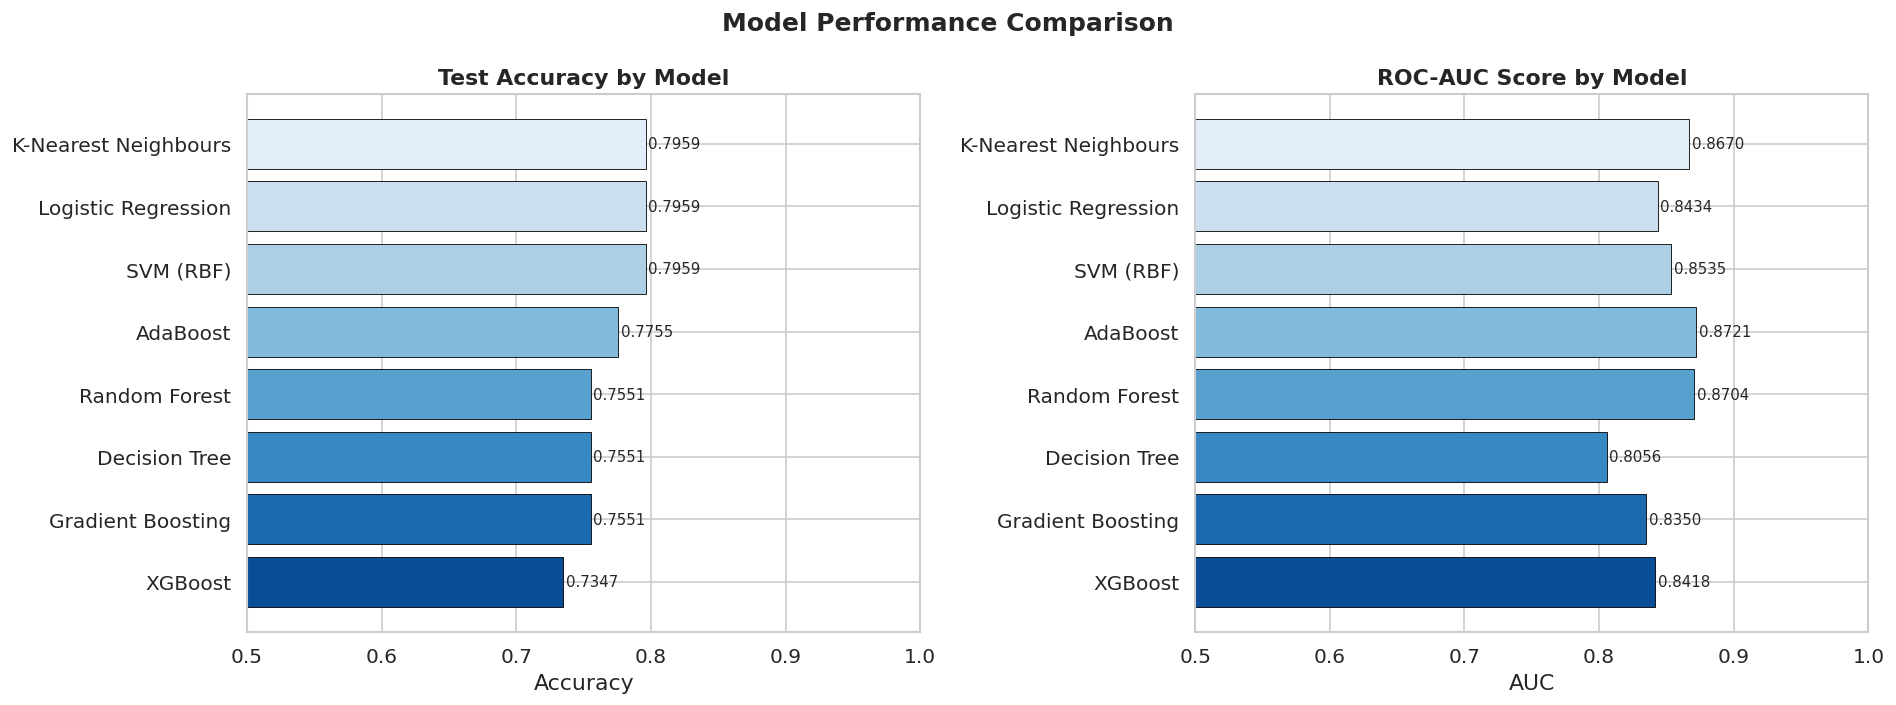

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_bar = sns.color_palette("Blues_r", len(results_df))

sorted_by_acc = results_df.sort_values("Test Acc")
axes[0].barh(sorted_by_acc["Model"], sorted_by_acc["Test Acc"],
             color=palette_bar, edgecolor="black", linewidth=0.5)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_title("Test Accuracy by Model", fontweight="bold")
axes[0].set_xlabel("Accuracy")
for i, v in enumerate(sorted_by_acc["Test Acc"]):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

axes[1].barh(sorted_by_acc["Model"], sorted_by_acc["ROC-AUC"],
             color=palette_bar, edgecolor="black", linewidth=0.5)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title("ROC-AUC Score by Model", fontweight="bold")
axes[1].set_xlabel("AUC")
for i, v in enumerate(sorted_by_acc["ROC-AUC"]):
    axes[1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
best_name   = results_df.iloc[0]["Model"]
best_res    = next(r for r in results if r["Model"] == best_name)
best_model  = best_res["_model"]
y_pred_best = best_res["_y_pred"]
y_proba_best = best_res["_y_proba"]

print(f"Best Model  : {best_name}")
print(f"Test Acc    : {best_res['Test Acc']:.4f}")
print(f"ROC-AUC     : {best_res['ROC-AUC']:.4f}")
print(f"CV Mean Acc : {best_res['CV Mean']:.4f} +/- {best_res['CV Std']:.4f}")

Best Model  : Logistic Regression
Test Acc    : 0.7959
ROC-AUC     : 0.8434
CV Mean Acc : 0.8018 +/- 0.0490


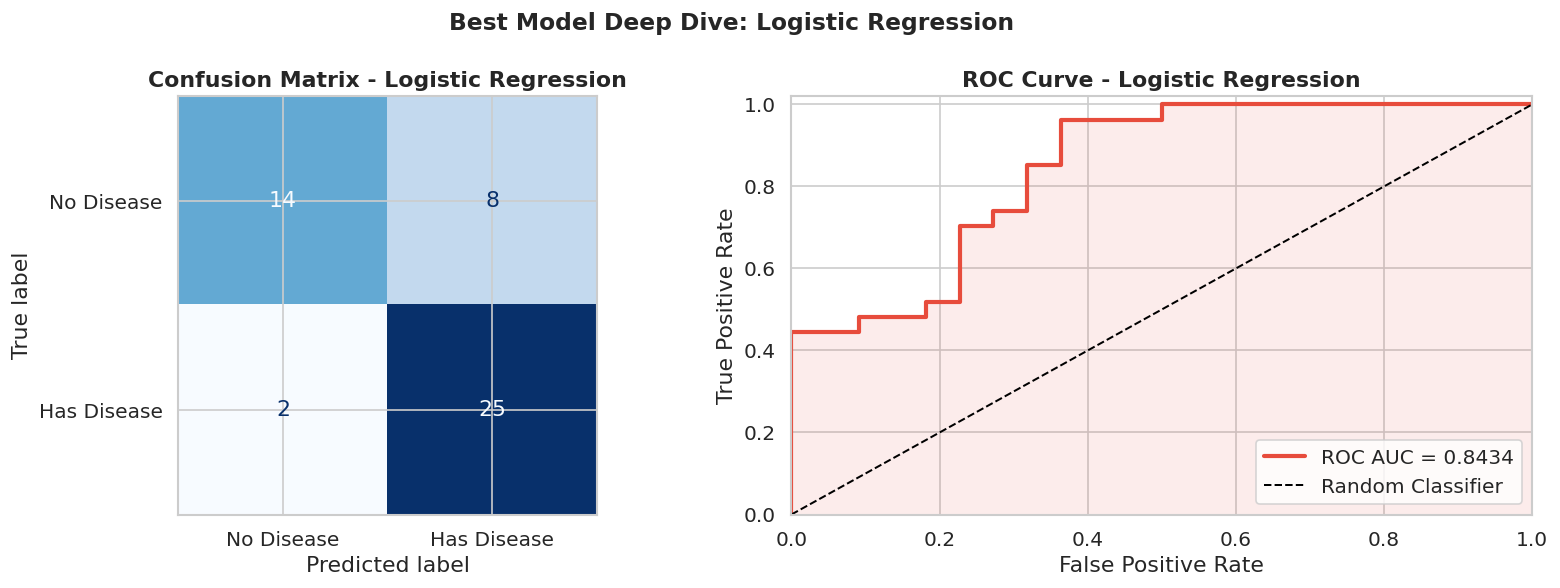

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Has Disease"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix - {best_name}", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_val = roc_auc_score(y_test, y_proba_best)
axes[1].plot(fpr, tpr, color="#E74C3C", lw=2.5, label=f"ROC AUC = {auc_val:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#E74C3C")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve - {best_name}", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle(f"Best Model Deep Dive: {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

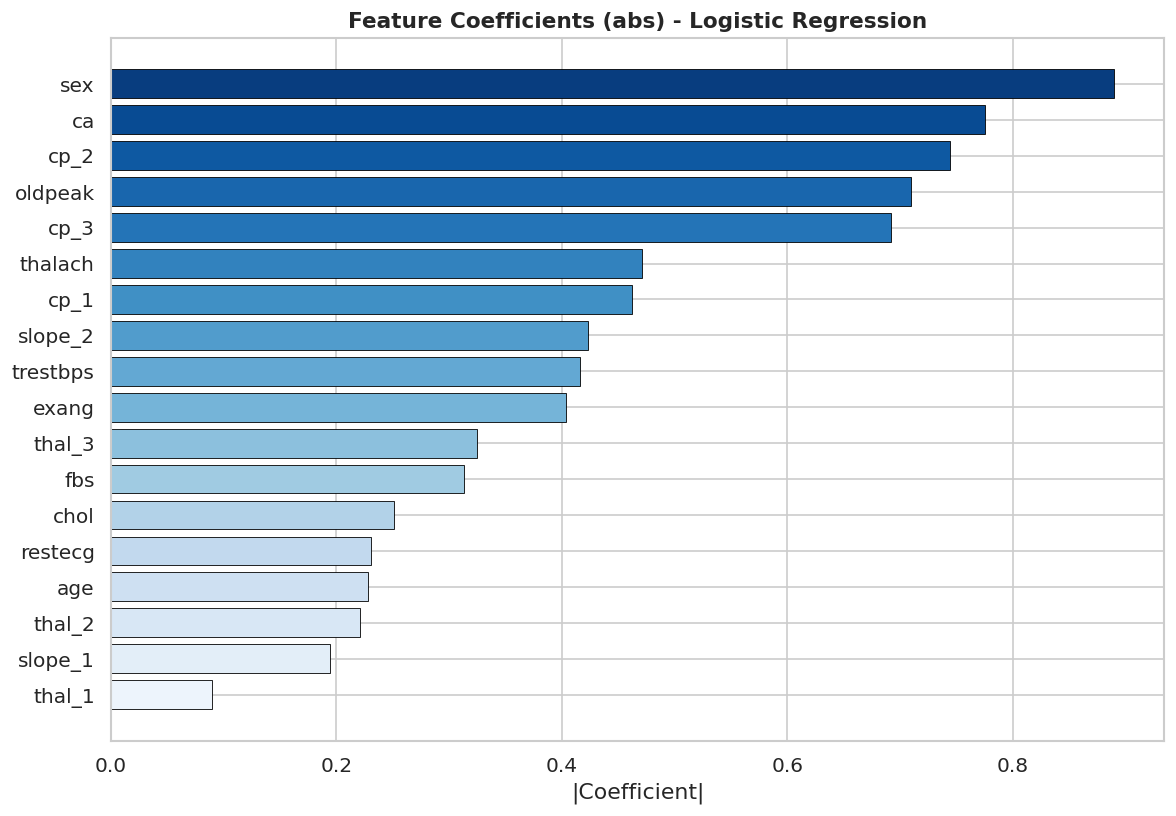

In [31]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    colors_fi = sns.color_palette("Blues", len(fi))
    plt.barh(fi.index, fi.values, color=colors_fi, edgecolor="black", linewidth=0.5)
    plt.title(f"Feature Importances - {best_name}", fontweight="bold", fontsize=13)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    fi = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    colors_fi = sns.color_palette("Blues", len(fi))
    plt.barh(fi.index, fi.values, color=colors_fi, edgecolor="black", linewidth=0.5)
    plt.title(f"Feature Coefficients (abs) - {best_name}", fontweight="bold", fontsize=13)
    plt.xlabel("|Coefficient|")
    plt.tight_layout()
    plt.show()

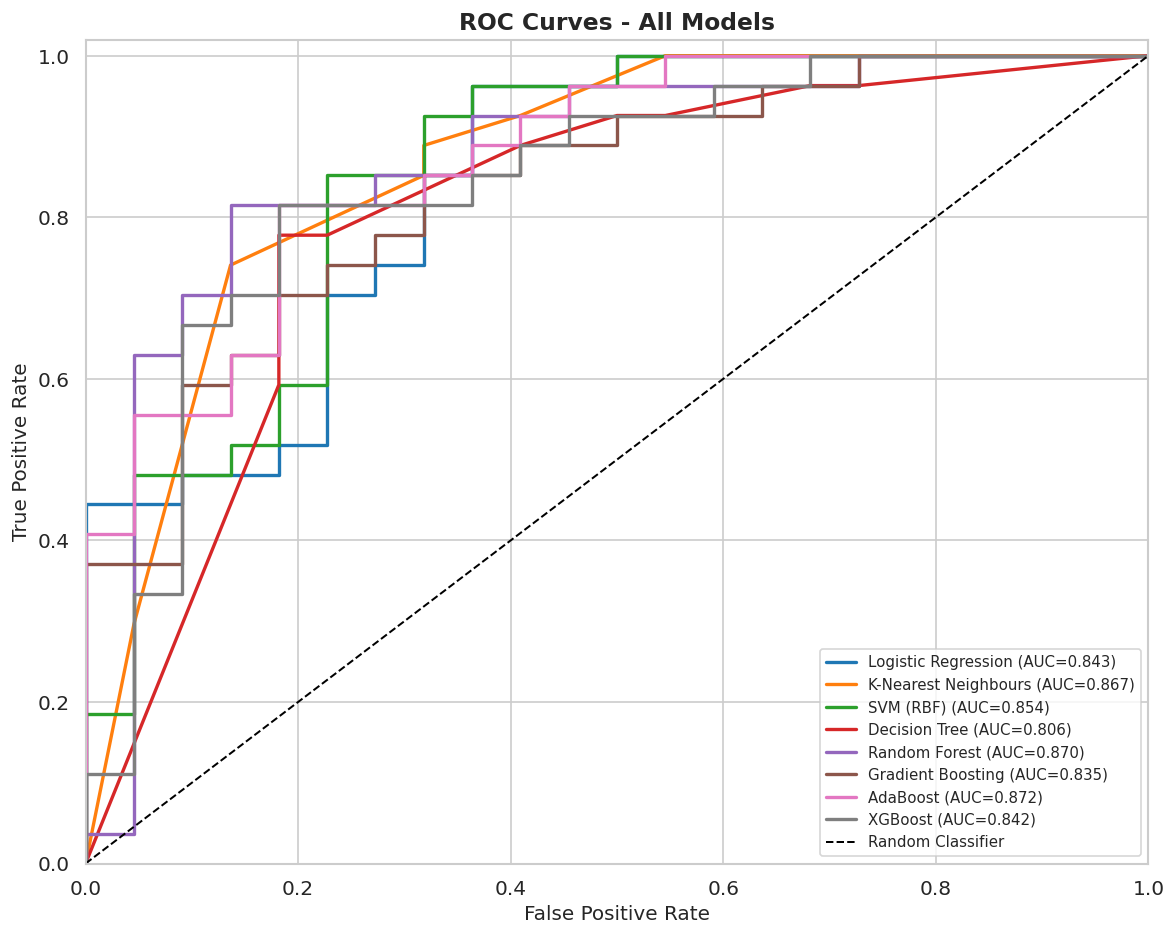

In [32]:
plt.figure(figsize=(10, 8))
palette_roc = sns.color_palette("tab10", len(results))

for i, r in enumerate(results):
    if r["_y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["_y_proba"])
        auc = roc_auc_score(y_test, r["_y_proba"])
        plt.plot(fpr, tpr, lw=2, color=palette_roc[i],
                 label=f"{r['Model']} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [33]:
import os
save_dir = "saved_model"
os.makedirs(save_dir, exist_ok=True)

model_path  = os.path.join(save_dir, "best_model.pkl")
scaler_path = os.path.join(save_dir, "scaler.pkl")

joblib.dump(best_model, model_path)
joblib.dump(scaler,     scaler_path)

print(f"Best model ({best_name}) saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Best model (Logistic Regression) saved to: saved_model/best_model.pkl
Scaler saved to: saved_model/scaler.pkl


In [34]:
# Verify: reload and run predictions
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

sample    = X_test.iloc[:5]
sample_sc = loaded_scaler.transform(sample)
preds     = loaded_model.predict(sample_sc)
proba     = loaded_model.predict_proba(sample_sc)[:, 1]

verify_df = pd.DataFrame({
    "Actual":      y_test.iloc[:5].values,
    "Predicted":   preds,
    "Probability": proba.round(4),
    "Correct":     (y_test.iloc[:5].values == preds)
})
print("Verification - Sample Predictions:")
print(verify_df.to_string(index=False))

Verification - Sample Predictions:
 Actual  Predicted  Probability  Correct
      0          0       0.2139     True
      1          0       0.1837    False
      1          1       0.9593     True
      0          0       0.0021     True
      1          1       0.9666     True


In [35]:
print("=" * 55)
print("     HEART DISEASE PREDICTION - SUMMARY")
print("=" * 55)
print(f"  Dataset          : {df.shape[0]} samples, {df.shape[1]} features")
print(f"  Train/Test split : 80% / 20% (stratified)")
print(f"  Models evaluated : {len(results)}")
print(f"  Best model       : {best_name}")
print(f"  Test Accuracy    : {best_res['Test Acc']:.4f}")
print(f"  ROC-AUC          : {best_res['ROC-AUC']:.4f}")
print(f"  CV Mean Acc.     : {best_res['CV Mean']:.4f} +/- {best_res['CV Std']:.4f}")
print(f"  Model saved to   : saved_model/best_model.pkl")
print("=" * 55)

     HEART DISEASE PREDICTION - SUMMARY
  Dataset          : 241 samples, 14 features
  Train/Test split : 80% / 20% (stratified)
  Models evaluated : 8
  Best model       : Logistic Regression
  Test Accuracy    : 0.7959
  ROC-AUC          : 0.8434
  CV Mean Acc.     : 0.8018 +/- 0.0490
  Model saved to   : saved_model/best_model.pkl
